# นำเข้าข้อมูล

In [1]:
import pandas as pd

# 1. ใส่ลิงก์ป่าตอง
url_patong = 'https://raw.githubusercontent.com/natthaphonmint/wave_prediction_project/refs/heads/main/wave_data/Patong_Phuket_Data.csv'

# 2. อ่านข้อมูล
PaTongPhuket = pd.read_csv(url_patong)

# 3. ลองแสดงผล
PaTongPhuket.head()

,Time,Significant height of\ncombined wind waves and swell,Significant height of total swell,Significant height of wind waves,10m v-component of wind,10m u-component of wind,Instantaneous 10m wind gust,Mean wave direction,Mean wave period,2m temperature,Sea surface temperature
0,1/1/2018 0.00,0.819530,0.512232,0.596436,-5.857641,-1.347422,8.788392,93.266464,4.970300,299.608520,301.705241
1,1/1/2018 1.00,0.806473,0.516237,0.576659,-5.828161,-1.395849,8.524141,94.748993,5.006505,299.633402,301.705241
2,1/1/2018 2.00,0.789961,0.513183,0.559022,-5.819311,-1.313538,8.112156,95.893707,5.018085,299.714030,301.705241
3,1/1/2018 3.00,0.773173,0.509671,0.538153,-5.572749,-0.925797,7.469082,97.431259,5.024179,299.766561,301.705241
4,1/1/2018 4.00,0.752750,0.576924,0.464689,-5.283966,-0.376038,6.867215,99.879059,5.049937,299.849436,301.705241


In [ ]:
display(f"Start date: {PaTongPhuket.index.min()}")
display(f"End date: {PaTongPhuket.index.max()}")

'Start date: 0'

'End date: 71543'

# การทำความสะอาดข้อมูลและเตรียมข้อมูล

In [ ]:
!pip install missingno

<Axes: >

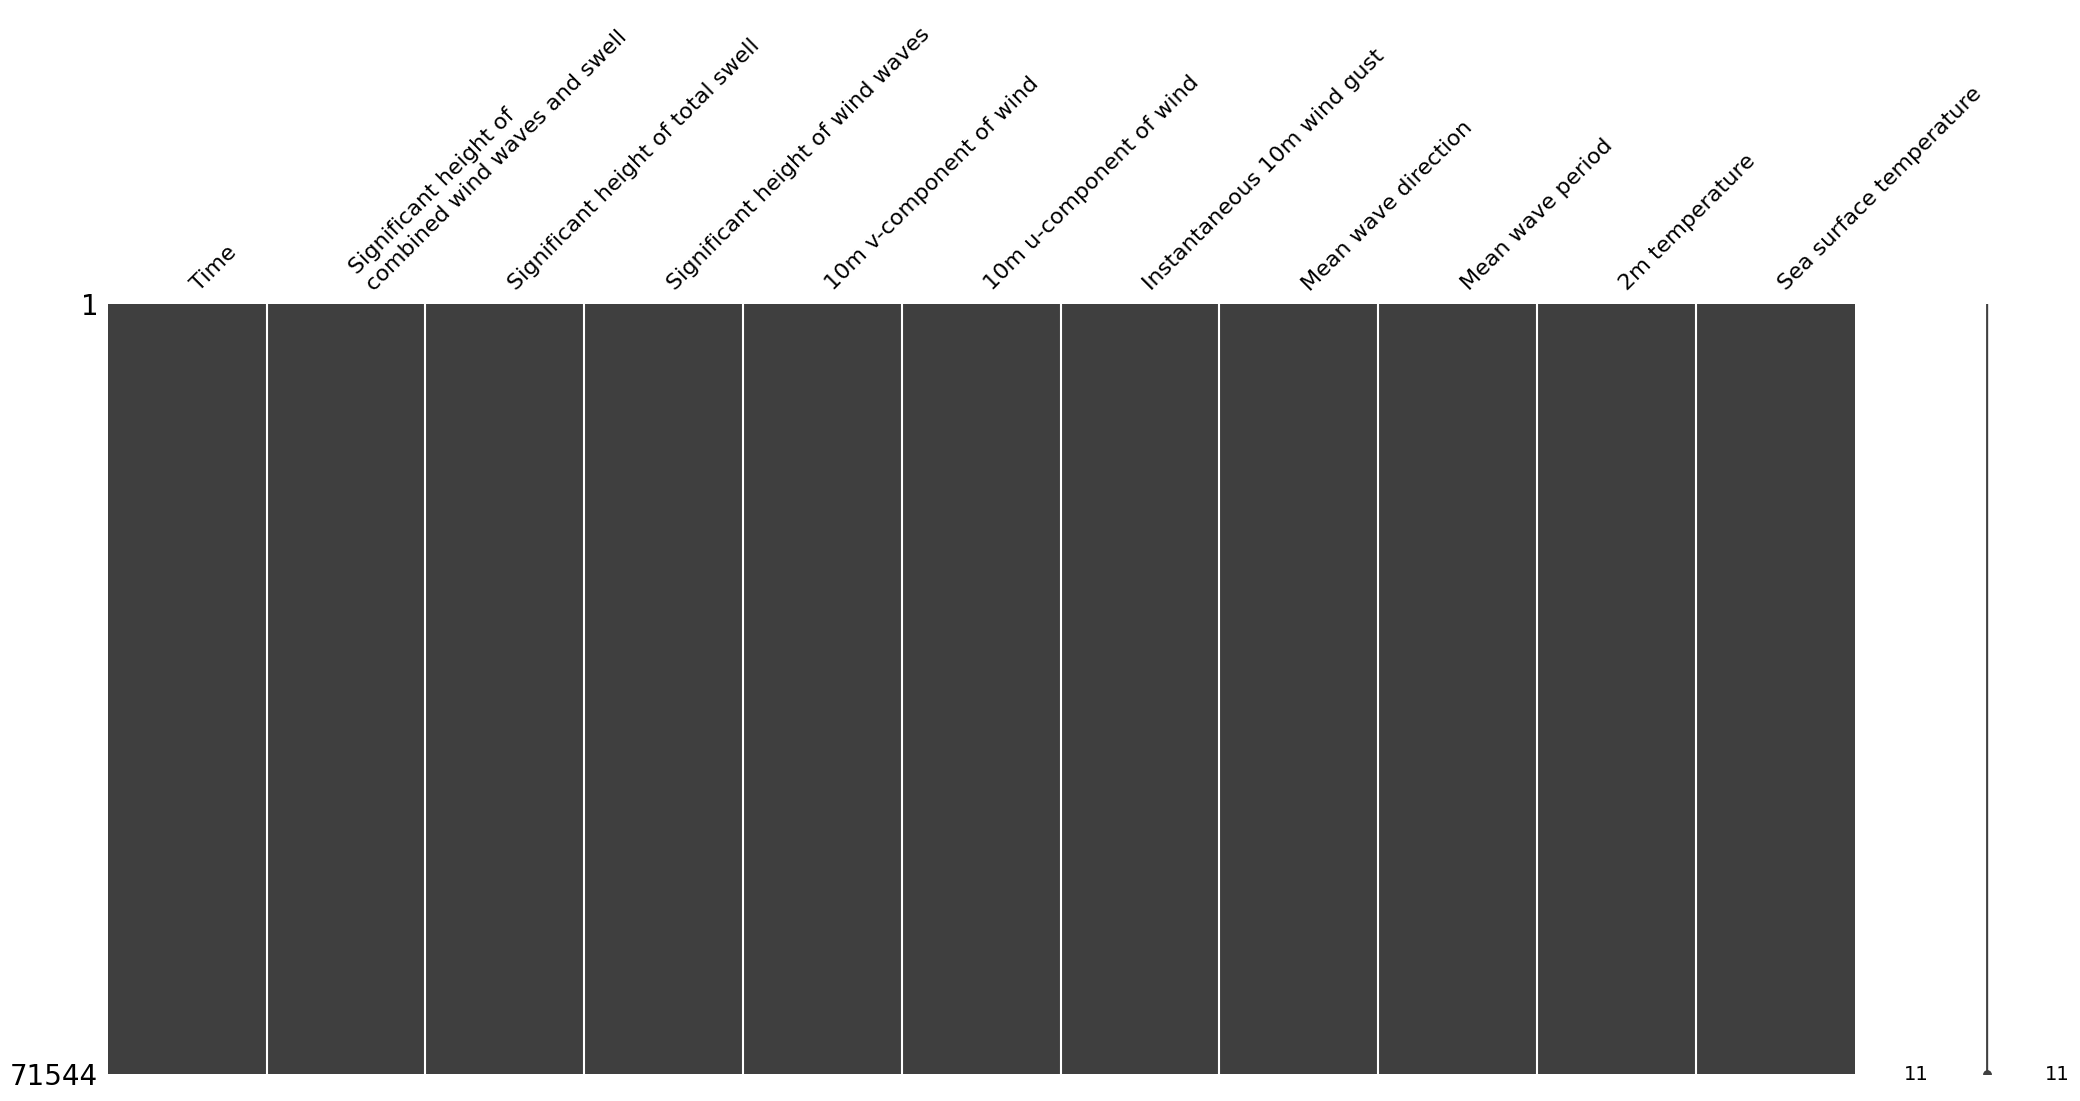

In [ ]:
import missingno as msno
msno.matrix(PaTongPhuket)

คอลัมน์ทั้ง 8 คอลัมน์ ไม่มีค่าที่หายไป

In [ ]:
# กำหนดให้คอลัมน์ 'Time' เป็น Index ของ DataFrame และแปลงเป็น DatetimeIndex
# ก่อนอื่น ทำความสะอาดคอลัมน์ 'Time' โดยการลบช่องว่างนำหน้าและตามหลัง
PaTongPhuket['Time'] = PaTongPhuket['Time'].str.strip()

# สร้างฟังก์ชันเพื่อทำให้รูปแบบเวลาเป็นมาตรฐาน โดยเปลี่ยน 'HH.MM' เป็น 'HH:MM'
def standardize_time_separator(time_str):
    if isinstance(time_str, str):
        parts = time_str.split(' ')
        if len(parts) == 2:
            date_part, time_part = parts
            if '.' in time_part: # ตรวจสอบว่ามีจุดในส่วนของเวลาหรือไม่
                time_part = time_part.replace('.', ':')
            return f"{date_part} {time_part}"
    return time_str # คืนค่าเดิมหากไม่ใช่ string หรือรูปแบบไม่ตรงกัน

PaTongPhuket['Time'] = PaTongPhuket['Time'].apply(standardize_time_separator)

PaTongPhuket_indexed = PaTongPhuket.set_index('Time')
# เมื่อทำรูปแบบเวลาเป็นมาตรฐานแล้ว สามารถใช้ format ที่แน่นอนได้
PaTongPhuket_indexed.index = pd.to_datetime(PaTongPhuket_indexed.index, format='%d/%m/%Y %H:%M')

# แสดงข้อความและ 5 แถวแรกของ DataFrame เพื่อให้เห็นว่าคอลัมน์ 'Time' ได้กลายเป็น Index
display("DataFrame with 'Time' as datetime index:")
display(PaTongPhuket_indexed.head())

# แสดงชนิดข้อมูลของแต่ละคอลัมน์
display("Data types including index type:")
display(PaTongPhuket_indexed.dtypes)

"DataFrame with 'Time' as datetime index:"

,Significant height of\ncombined wind waves and swell,Significant height of total swell,Significant height of wind waves,10m v-component of wind,10m u-component of wind,Instantaneous 10m wind gust,Mean wave direction,Mean wave period,2m temperature,Sea surface temperature
Time,,,,,,,,,,
2018-01-01 00:00:00,0.819530,0.512232,0.596436,-5.857641,-1.347422,8.788392,93.266464,4.970300,299.608520,301.705241
2018-01-01 01:00:00,0.806473,0.516237,0.576659,-5.828161,-1.395849,8.524141,94.748993,5.006505,299.633402,301.705241
2018-01-01 02:00:00,0.789961,0.513183,0.559022,-5.819311,-1.313538,8.112156,95.893707,5.018085,299.714030,301.705241
2018-01-01 03:00:00,0.773173,0.509671,0.538153,-5.572749,-0.925797,7.469082,97.431259,5.024179,299.766561,301.705241
2018-01-01 04:00:00,0.752750,0.576924,0.464689,-5.283966,-0.376038,6.867215,99.879059,5.049937,299.849436,301.705241


'Data types including index type:'

,0
Significant height of\ncombined wind waves and swell,float64
Significant height of total swell,float64
Significant height of wind waves,float64
10m v-component of wind,float64
10m u-component of wind,float64
Instantaneous 10m wind gust,float64
Mean wave direction,float64
Mean wave period,float64
2m temperature,float64
Sea surface temperature,float64


In [ ]:
# ตรวจสอบ time difference ระหว่างแถวที่ติดกัน
time_diff = PaTongPhuket_indexed.index.to_series().diff().dropna()

# สร้างเวกเตอร์ของ time difference
time_diff_vector = time_diff.values

# ตรวจสอบว่า time difference ทั้งหมดเท่ากับ 1 ชั่วโมงหรือไม่
# เนื่องจาก time_diff เป็น TimedeltaIndex, เราสามารถเปรียบเทียบกับ pd.Timedelta(hours=1)
is_one_hour = (time_diff == pd.Timedelta(hours=1))

# ตรวจสอบว่ามีค่าใดที่ไม่เท่ากับ 1 ชั่วโมงหรือไม่
if not is_one_hour.all():
    display("พบความแตกต่างของเวลาที่ไม่เท่ากับ 1 ชั่วโมง:")
    display(time_diff[~is_one_hour])
else:
    display("ความแตกต่างของเวลาในแต่ละแถวเท่ากับ 1 ชั่วโมงทั้งหมด")

    display("ตารางแสดงความแตกต่างของเวลาในแต่ละแถว:")
display(time_diff.head())
display("...")
display(time_diff.tail())

'ความแตกต่างของเวลาในแต่ละแถวเท่ากับ 1 ชั่วโมงทั้งหมด'

'ตารางแสดงความแตกต่างของเวลาในแต่ละแถว:'

,Time
Time,
2018-01-01 01:00:00,0 days 01:00:00
2018-01-01 02:00:00,0 days 01:00:00
2018-01-01 03:00:00,0 days 01:00:00
2018-01-01 04:00:00,0 days 01:00:00
2018-01-01 05:00:00,0 days 01:00:00


'...'

,Time
Time,
2026-02-28 19:00:00,0 days 01:00:00
2026-02-28 20:00:00,0 days 01:00:00
2026-02-28 21:00:00,0 days 01:00:00
2026-02-28 22:00:00,0 days 01:00:00
2026-02-28 23:00:00,0 days 01:00:00


In [ ]:
# Check for duplicate rows
duplicate_rows = PaTongPhuket[PaTongPhuket.duplicated()]

if duplicate_rows.empty:
    display("ไม่มีแถวที่ซ้ำกันในข้อมูล")
else:
    display("พบแถวที่ซ้ำกันในข้อมูล:")
    display(duplicate_rows)

'ไม่มีแถวที่ซ้ำกันในข้อมูล'

In [ ]:
# ตรวจสอบว่ามี "เวลา" (ซึ่งเป็น Index) ซ้ำซ้อนกันหรือไม่
index_duplicates = PaTongPhuket_indexed.index.duplicated()

if not index_duplicates.any():
    display("ไม่พบแถวข้อมูลที่มี 'เวลาซ้ำซ้อน' (Unique Timestamps)")
    display("ทุกจุดเวลาในชุดข้อมูลนี้มีข้อมูลเพียงชุดเดียว")
else:
    display("พบแถวข้อมูลที่มี 'เวลาซ้ำซ้อน' (Duplicate Timestamps)!")

    # แสดงให้เห็นว่าเวลาไหนที่ซ้ำ
    duplicate_times = PaTongPhuket_indexed.index[index_duplicates].unique()
    display(f"พบเวลาที่ซ้ำซ้อนกัน {len(duplicate_times)} จุดเวลา:")
    display(duplicate_times)

    # แสดงแถวที่ซ้ำทั้งหมด (ทั้งแถวเก่าและแถวใหม่ที่ซ้ำกัน)
    display("แถวข้อมูลทั้งหมดที่มีเวลาซ้ำซ้อนกัน:")
    display(PaTongPhuket_indexed[PaTongPhuket_indexed.index.duplicated(keep=False)])

"ไม่พบแถวข้อมูลที่มี 'เวลาซ้ำซ้อน' (Unique Timestamps)"

'ทุกจุดเวลาในชุดข้อมูลนี้มีข้อมูลเพียงชุดเดียว'